This one is an update to a previous script "BTMS T Solver.ipynb", which aims to locate the temperature distribution for liquid cooling BTMS. Also, this one integrates several cells in notebook 'Liquid cooling BTMS 1D modelling.ipynb', which was developed based a previous script shared by Liu Mingxin. 



In [27]:
# 读取本地 CFD .out 文件，并与液冷结果、BLC max/min 画在同一张图上
import os
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 本地 .out 数据文件夹。
# 数据文件就在程序/notebook 所在文件夹时，不需要改路径；直接放在同一目录即可。
# 在 Jupyter 中这里读取当前 notebook 的运行目录。
CFD_DATA_DIR = os.path.join(os.getcwd(), "data","HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max")


def read_out_temperature(filename, series_name, data_dir=CFD_DATA_DIR):
    """
    读取本地文件夹中的 .out 文件。
    文件应至少包含两列数值：时间/步数 和 温度值。
    支持空格、Tab、逗号分隔；自动跳过表头和注释行。

    对 Fluent report .out 文件，常见格式为：
        Time Step, report-def, flow-time
    本函数默认取第 1 个数值为横坐标、第 2 个数值为温度。
    """
    path = Path(data_dir) / filename
    if not path.exists():
        raise FileNotFoundError(
            f"未找到 {path}。请确认 {filename} 和这个 notebook/program 放在同一个文件夹，"
            "或手动修改 CFD_DATA_DIR。"
        )

    rows = []
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(("#", "//")):
                continue

            # 提取每一行中的数值，兼容 scientific notation。
            nums = re.findall(r"[-+]?(?:\d+\.\d*|\.\d+|\d+)(?:[eE][-+]?\d+)?", line)
            if len(nums) >= 2:
                rows.append([float(nums[0]), float(nums[1])])

    if not rows:
        raise ValueError(f"{path} 中没有读到有效的两列数值数据：time 和 temperature。")

    data = pd.DataFrame(rows, columns=["time_s", "temperature"])
    # Check the values are within the expected range for temperature (e.g., 0-100 °C)
    
    data["temperature"] = data["temperature"] - 273.15  # 转换为摄氏度
    
    if not ((10 <= data["temperature"]).all() and (data["temperature"] <= 100).all()):
        print(f"WARNING: {series_name} is ignored since contains temperature values outside the expected range 10-100 °C. ")
        print(f"Values: min={data['temperature'].min():.2f}, max={data['temperature'].max():.2f}")
        return None    
    
    data.name = series_name
    return data[["time_s", "temperature"]]


def try_read_out_temperature(filename, series_name, data_dir=CFD_DATA_DIR):
    """读取 CFD .out 文件；如果文件不存在则跳过，避免只缺少某一组数据时整段绘图失败。"""
    try:
        data = read_out_temperature(filename, series_name, data_dir=data_dir)
        
        if data is None:
            print(f"WARNING: {series_name} contains no valid data and is ignored.")
            return None
        
        print(f"Loaded {series_name}: {Path(data_dir) / filename}, rows={len(data)}")
        return data
    
    except Exception as exc:
        print(f"WARNING: {exc}")
        return None


CFD 数据读取目录: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data\HP02E030112A2  result_T profile_liquid cooling_CFD_avg T per bat cell_20260705
Reading temperature data for battery cell 1 saved in bat1-rfile.out
Loaded bat01: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data\HP02E030112A2  result_T profile_liquid cooling_CFD_avg T per bat cell_20260705\bat1-rfile.out, rows=1201
Reading temperature data for battery cell 2 saved in bat2-rfile.out
Loaded bat02: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data\HP02E030112A2  result_T profile_liquid cooling_CFD_avg T per bat cell_20260705\bat2-rfile.out, rows=1201
Reading temperature data for battery cell 3 saved in bat3-rfile.out
Loaded bat03: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data\HP02E030112A2  result_T profile_liquid cooling_CFD_avg T per bat cell_20260705\bat3-rfile.out, rows=1201
Reading temperature data for battery cell 4 saved in bat4-rfile.out
Loaded bat04: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data\HP02E030112

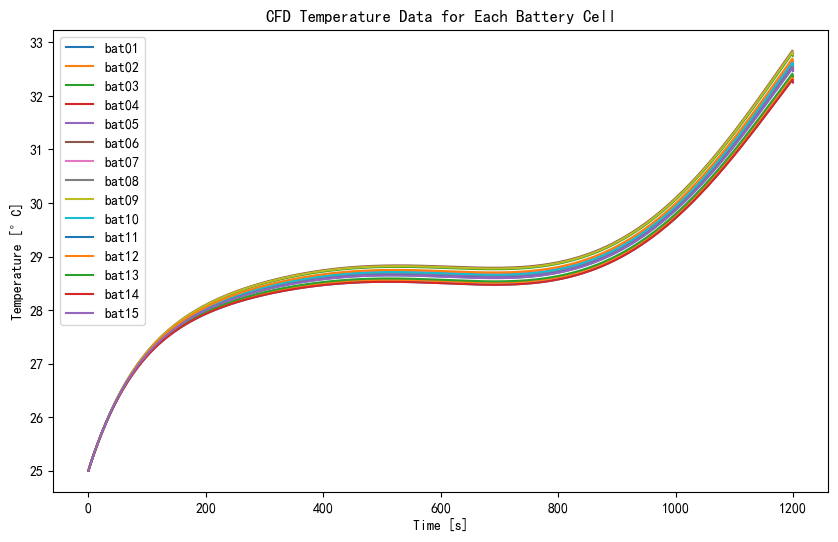

In [28]:
# Read all data saved in the dir to find out the maximum and minimum temperatures for liquid-cooled BTMS

CFD_DATA_DIR = os.path.join(os.getcwd(), "data","HP02E030112A2  result_T profile_liquid cooling_CFD_avg T per bat cell_20260705")

print(f"CFD 数据读取目录: {CFD_DATA_DIR}")
cfd_series = {}

for i in range(1, 16): # temperature for each battery cell, 1-15
    filename = f"bat{i}-rfile.out"
    label = f"bat{i:02d}"
    
    print(f"Reading temperature data for battery cell {i} saved in {filename}")
    
    data = try_read_out_temperature(filename, label, data_dir=CFD_DATA_DIR)
    
    if data is not None:
        cfd_series[label] = data
    else: pass
    
# plot all data for selection
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for label, data in cfd_series.items():
    plt.plot(data["time_s"], data["temperature"], label=label)
    
plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.title("CFD Temperature Data for Each Battery Cell")
plt.legend()
plt.show()

In [29]:
# Data sent by Liu, who find the maximum and minimum temperatures for liquid-cooled BTMS.

CFD_DATA_DIR = os.path.join(os.getcwd(), "data","HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max")

print(f"CFD 数据读取目录: {CFD_DATA_DIR}")

# 要读取并绘制的 CFD 数据文件。
# 新增的两组数据为 min_avg.out 和 max_avg.out，图例分别为 CFD_min_avg 和 CFD_max_avg。
CFD_SERIES_FILES = {
    "CFD_max": "max.out",
    "CFD_min": "min.out",   
    "CFD_max_avg": "max_avg.out",
    "CFD_min_avg": "min_avg.out",
}

# 读取本地 CFD 数据。
cfd_series = []
for label, filename in CFD_SERIES_FILES.items():
    data = try_read_out_temperature(filename, label) 
    if data is not None:
        cfd_series.append((label, data))

CFD 数据读取目录: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max
Loaded CFD_max: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max\max.out, rows=1201
Loaded CFD_min: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max\min.out, rows=1201
Loaded CFD_max_avg: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max\max_avg.out, rows=1201
Loaded CFD_min_avg: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max\min_avg.out, rows=1201


In [30]:
# Data presented in the paper [[zhang2024PerformanceInvestigation]]  
# plot them as references

# 额外给定数据：BLC-max
BLC_max = np.array([
    [0, 298.16],
    [31.30, 299.30],
    [70.31, 300.34],
    [115.61, 301.12],
    [160.61, 301.74],
    [197.32, 302.22],
    [238.62, 302.60],
    [277.63, 302.88],
    [323.52, 303.12],
    [360.23, 303.27],
    [399.24, 303.39],
    [435.95, 303.47],
    [479.54, 303.50],
    [520.84, 303.51],
    [562.14, 303.52],
    [598.85, 303.53],
    [640.15, 303.54],
    [676.86, 303.55],
    [718.16, 303.56],
    [759.46, 303.58],
    [798.47, 303.63],
    [839.77, 303.72],
    [874.19, 303.86],
    [917.78, 304.08],
    [959.08, 304.39],
    [1002.68, 304.83],
    [1039.39, 305.43],
    [1076.10, 306.18],
    [1119.69, 307.10],
    [1158.70, 308.22],
    [1197.71, 309.47],
], dtype=float)
# 额外给定数据：BLC-min
BLC_min = np.array([
    [0, 298.16],
    [39.76, 298.42],
    [81.92, 298.62],
    [121.98, 298.76],
    [157.81, 298.86],
    [197.87, 298.93],
    [240.04, 299.00],
    [286.44, 299.05],
    [320.18, 299.07],
    [358.14, 299.09],
    [402.42, 299.11],
    [438.28, 299.13],
    [478.34, 299.14],
    [520.52, 299.14],
    [558.49, 299.15],
    [604.89, 299.16],
    [649.17, 299.17],
    [678.70, 299.17],
    [720.87, 299.19],
    [763.05, 299.20],
    [798.91, 299.22],
    [843.19, 299.26],
    [883.26, 299.30],
    [923.32, 299.35],
    [961.27, 299.42],
    [995.01, 299.50],
    [1041.39, 299.63],
    [1079.34, 299.78],
    [1121.50, 299.99],
    [1161.54, 300.24],
    [1200, 300.56],
], dtype=float)





In [31]:

# read the newest 18650FAC heat-generation profile from the same directory as this notebook

import os
import sys
import numpy as np
import pandas as pd

def normalize_column_name(name):
    """Normalize column names for robust matching."""
    return str(name).strip().lower().replace(" ", "")


def find_column(dataframe, candidates):
    """Find a column by case/space-insensitive matching."""
    normalized = {normalize_column_name(col): col for col in dataframe.columns}
    for candidate in candidates:
        key = normalize_column_name(candidate)
        if key in normalized:
            return normalized[key]
    raise KeyError(f"None of the expected columns were found: {candidates}. Existing columns: {list(dataframe.columns)}")


def numeric_series(dataframe, candidates):
    """Return a numeric Series from the first matching candidate column."""
    col = find_column(dataframe, candidates)
    series = pd.to_numeric(dataframe[col], errors="coerce").dropna()
    return col, series


def first_float_or_none(dataframe, candidates):
    """Read the first numeric value from a candidate column, if it exists."""
    try:
        _, values = numeric_series(dataframe, candidates)
    except KeyError:
        return None
    if values.empty:
        return None
    return float(values.iloc[0])



In [32]:


file_name = os.path.join(os.getcwd(), "data", "HP02E030111A1  result_Q_liquid cooling_18650FAC.xlsx") 
df = pd.read_excel(file_name, sheet_name="Sheet1")

# Geometry values in the new 18650FAC file.
H_bat_from_file = first_float_or_none(df, ["H(高度)", "H", "height", "Height"])
D_bat_from_file = first_float_or_none(df, ["D(直径)", "D", "diameter", "Diameter"])
H_bat_for_q = H_bat_from_file if H_bat_from_file is not None else 65e-3
D_bat_for_q = D_bat_from_file if D_bat_from_file is not None else 18e-3
V_bat_for_q = np.pi * D_bat_for_q ** 2 / 4.0 * H_bat_for_q

# The newest 18650FAC file has a complete 1200-row Qbat(W) column, so use it
# directly as the single-cell heat-generation power. Do not use Qpack(W), because
# this BLC reproduction uses 15 cells and the total module heat is assembled from
# 15 single-cell values inside the model.
try:
    power_col, power_series = numeric_series(df, ["Qbat(W)", "Qbat", "qbat(W)"])
    power_generation_data = power_series.to_numpy(dtype=float)
    power_source_note = f"{power_col} directly, single-cell heat generation"
except KeyError:
    # Fallback: if a future workbook omits Qbat(W), compute single-cell power from qbat(W/m^3).
    qvol_col, qvol_series = numeric_series(df, ["qbat(W/m^3)", "qbat(W/m3)", "qbat", "qgen(W/m^3)", "qgen"])
    power_generation_data = qvol_series.to_numpy(dtype=float) * V_bat_for_q
    power_col = qvol_col
    power_source_note = f"{qvol_col} multiplied by computed cell volume {V_bat_for_q:.8e} m^3"

# Each row is one 1-second heat-generation interval. 1200 rows => states from 0 to 1200 s.
dt = 1.0
heat_generation_steps = len(power_generation_data)
if heat_generation_steps != 1200:
    print(f"WARNING: heat-generation data contains {heat_generation_steps} rows, not 1200 rows.")

print(f"Loaded heat-generation data from: {file_name}")
print(f"Power source: {power_source_note}")
print(f"Heat-generation intervals: {heat_generation_steps}; simulation end time: {heat_generation_steps*dt:.0f} s")
print(f"Power range: min={np.min(power_generation_data):.6g} W, max={np.max(power_generation_data):.6g} W, mean={np.mean(power_generation_data):.6g} W per cell")
print(f"Battery geometry from file: H={H_bat_from_file} m, D={D_bat_from_file} m, V={V_bat_for_q:.8e} m^3")


Loaded heat-generation data from: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data\HP02E030111A1  result_Q_liquid cooling_18650FAC.xlsx
Power source: Qbat(W) directly, single-cell heat generation
Heat-generation intervals: 1200; simulation end time: 1200 s
Power range: min=0.927676 W, max=2.62219 W, mean=1.27182 W per cell
Battery geometry from file: H=0.065 m, D=0.018 m, V=1.65404853e-05 m^3


In [33]:
# Battery parameters for NCR18650PF cylindrical cells used in the Zhang et al. 2024 BLC case.
# The heat-generation file has 1200 rows. With dt = 1 s, the state arrays must have 1201 rows:
# t = 0, 1, 2, ..., 1200 s.

T_bat_init = 25.0  # initial battery temperature in Celsius
cp_bat = 877.24    # J/(kg·K), from the paper table for the 18650 cell
m_bat = 47e-3      # kg, mass of one 18650 cell
D_bat = D_bat_from_file if D_bat_from_file is not None else 18e-3  # m
H_bat = H_bat_from_file if H_bat_from_file is not None else 65e-3  # m

# 15-cell BLC module layout. The 1D liquid model uses one thermal segment per cell.
N_r, N_c = 3, 5
N_cells = N_r * N_c
num_segment = N_cells

A_battery = np.pi * D_bat * H_bat  # lateral surface area of one cylindrical cell, m^2


In [34]:

num_time_steps = heat_generation_steps + 1

# Adiabatic single-cell temperature rise from the new heat-generation profile.
T_bat_wo_cooling = np.zeros(num_time_steps)
T_bat_wo_cooling[0] = T_bat_init

for i in range(1, num_time_steps):
    # power_generation_data[i-1] is the heat generated during interval (i-1, i].
    dT = (power_generation_data[i - 1] * dt) / (m_bat * cp_bat)
    T_bat_wo_cooling[i] = T_bat_wo_cooling[i - 1] + dT

print(
    f"Battery setup: N_cells={N_cells}, m_bat={m_bat:.6g} kg, cp_bat={cp_bat:.6g} J/(kg·K), "
    f"D_bat={D_bat:.6g} m, H_bat={H_bat:.6g} m"
)
print(f"Simulation time grid: {num_time_steps} state points, t = 0 to {(num_time_steps-1)*dt:.0f} s")


Battery setup: N_cells=15, m_bat=0.047 kg, cp_bat=877.24 J/(kg·K), D_bat=0.018 m, H_bat=0.065 m
Simulation time grid: 1201 state points, t = 0 to 1200 s


In [35]:
# Initial conditions and BLC liquid-cooling parameters
# BLC replication case from section 3.1: Tamb = 25 °C, Tin = 25 °C, Fc = 240 mL/min.
# Only bottom liquid cooling is retained; heat-pipe material data are intentionally not used.

import numpy as np

# channel geometries

D_channel = 4e-3      # m, circular channel diameter / hydraulic diameter
D_h = D_channel       # m, hydraulic diameter for circular channel, same as diameter
# Total fluid-domain length: 126 + 126 + 144 + 144 + 3*pi*8 mm
# L_channel_total = (126.0 + 126.0 + 144.0 + 144.0 + 3.0 * np.pi * 8.0) * 1e-3
L_channel_total = 144e-3 * 4 # for simplicity, use 4 straight segments of 144 mm each, ignoring the short 126 mm segments and the bends, this is a liquid channel with three U-bends. # Channel and heat-transfer areas
N_cool_seg = 20 # for the above channel layout, use 20 segments for the 1D model to balance resolution and computational cost.

A_channel_cross = np.pi * D_channel ** 2 / 4.0
P_channel_wet = np.pi * D_channel
# A_liq_total = P_channel_wet * L_channel_total / 2 # m^2, total wetted area of the channel; divide by 2 because only the upper half of the channel is in contact with the cell and thus participates in heat transfer with the liquid coolant.
A_liq_total = P_channel_wet * L_channel_total # m^2, total wetted area of the channel; assume all of it participates in heat transfer with the liquid coolant.

# Plate material for BLC: aluminum element/cold plate data from the paper.
k_plate = 202.4   # W/(m·K)
cp_plate = 871.0  # J/(kg·K), recorded only; cold-plate heat capacity is neglected
rho_plate = 2719.0 # kg/m^3, recorded only; cold-plate heat capacity is neglected

# Plate geometry for BLC
W_plate = 76e-3 # m, cold plate width, same as the paper
L_plate = 138e-3 # m, cold plate length, same as the paper
A_plate_total = W_plate * L_plate # m^2, total area of the cold

# A_HT_all = A_plate_total 
A_HT_all = A_liq_total

A_HT_seg = A_HT_all / N_cool_seg # m^2, heat transfer area for each segment 

# Liquid coolant settings
T_liq_in = 25.0  # °C
T_liq_in_K = T_liq_in + 273.15
p_liq = 101325  # Pa
fluid_liq = "Water"

# Coolant properties from the paper table
rho_liq_const = 998.2   # kg/m^3
cp_liq_const = 4182.0   # J/(kg·K)
k_liq_const = 0.6       # W/(m·K)

# Paper flow rate Fc = 240 mL/min. Convert volumetric flow rate to mass flow rate.
Fc_mL_min = 240.0
vol_flow_m3_s = Fc_mL_min * 1e-6 / 60.0  # 1 mL = 1e-6 m^3
m_dot_liq = rho_liq_const * vol_flow_m3_s # kg/s

V_cool_in = m_dot_liq / (rho_liq_const * A_channel_cross)
V_cool_char = V_cool_in

# print(f"u_cool_in = {u_cool_in}")

# Defines a map for the correspondence between the battery cell and liquid segment indices. 
# e.g., for 3*5 battery cells and a single liquid channel, if the liquid channel includes threes U-turns, the liquid channel can be devided into 20 segments, and thus, for the battery cells in the middle row, each cell corresponds to 2 coolant segments. 

# define the indices for N_seg = 15 battery cells in the 3*5 layout
# The ordering of coolant should follow the flow direction. 
cell_to_cool_map = {
    0: (0,),
    1: (1,),
    2: (2,),
    3: (3,),
    4: (4,),
    5: (9, 10),  # cell 5 (the first cell in the second row) corresponds to segements 9 and 10
    6: (8, 11),  # cell 6 corresponds to segements 6 and 11
    7: (7, 12),  # cell 7 corresponds to segements 7 and 12
    8: (6, 13),  # cell 8 corresponds to segements 6 and 13
    9: (5, 14),  # cell 9 corresponds to segements 5 and 14
    10: (19,),
    11: (18,),
    12: (17,),
    13: (16,),
    14: (15,),
}




In [36]:

import lib.BTMS_model as BTMS_model

# Dynamic viscosity is required for Re/Pr/Nu but is not listed in the paper table.
# Use CoolProp for viscosity only when available; otherwise use water viscosity near 25 °C.
try:
    import CoolProp.CoolProp as CP
    mu_liq_const = CP.PropsSI("V", "T", T_liq_in_K, "P", p_liq, fluid_liq)
    prop_source = "paper rho/cp/k; CoolProp viscosity"
except Exception as exc:
    mu_liq_const = 8.90e-4  # Pa·s, approximate water viscosity at 25 °C
    prop_source = f"paper rho/cp/k; fallback viscosity because CoolProp is unavailable: {exc}"

# Liquid-side Reynolds, Nusselt, h and resistances. Nu correlation remains unchanged.
Pr_liq = cp_liq_const * mu_liq_const / k_liq_const
Re_liq = m_dot_liq * D_h / (mu_liq_const * A_channel_cross)
Nu_liq = BTMS_model.liquid_nusselt_number(Re_liq, Pr_liq, heating=False)
htc_liq = Nu_liq * k_liq_const / D_h

k_plate = 202.4   # W/(m·K), aluminum cold plate conductivity from the paper
t_plate = 8e-3    # m, cold plate thickness from the paper
R_plate = t_plate / k_plate  # thermal resistance through the plate; 

htc_global = 1 / (R_plate + 1 / htc_liq)  # global heat transfer coefficient combining conduction and convection; 

debug = True  # set to True to print detailed parameters for verification

# print the above parameters for verification
print(f"Liquid coolant properties: {prop_source}")
print(f"Liquid inlet temperature: {T_liq_in:.2f} °C")
print(f"Mass flow rate: {m_dot_liq:.6g} kg/s")
print(f"Reynolds number: {Re_liq:.6g}")
print(f"Nusselt number: {Nu_liq:.6g}")
print(f"Convective heat transfer coefficient: h = {htc_liq:.6g} W/(m^2·K)")
print(f"Total channel length: {L_channel_total:.6g} m, total wetted perimeter: {P_channel_wet:.6g} m, total heat transfer area: {A_liq_total:.6g} m^2") 
print(f"Heat transfer area per segment: {A_HT_seg:.6g} m^2")


Liquid coolant properties: paper rho/cp/k; CoolProp viscosity
Liquid inlet temperature: 25.00 °C
Mass flow rate: 0.0039928 kg/s
Reynolds number: 1428
Nusselt number: 4.36
Convective heat transfer coefficient: h = 654 W/(m^2·K)
Total channel length: 0.576 m, total wetted perimeter: 0.0125664 m, total heat transfer area: 0.00723823 m^2
Heat transfer area per segment: 0.000361911 m^2


In [37]:
# Use a 0D model to calcualte the coolant outlet temperature as a reference

T_bat_history_0D = np.zeros(num_time_steps)
T_cool_history_0D = np.zeros(num_time_steps)
T_bat_history_0D[0] = T_bat_init
T_cool_history_0D[0] = T_liq_in
Q_cool_history_0D = np.zeros(num_time_steps)

for i in range(1, num_time_steps):
    
    T_cool_out_guess = T_cool_history_0D[i-1]
    # T_cool_bar_guess = 0.5 * (T_liq_in + T_cool_out_guess)
    T_cool_bar = T_liq_in
    T_bat_pre = T_bat_history_0D[i - 1]
    Q_HT = htc_global * A_HT_all * (T_bat_pre - T_cool_bar)  # heat transfer from battery to coolant
    
    dT_bat = (power_generation_data[i-1] * N_cells - Q_HT) / (m_bat * cp_bat * N_cells)  # temperature change in the battery
    
    dT_cool = Q_HT / (m_dot_liq * cp_liq_const)  # temperature change in the coolant
    
    T_cool_out = T_liq_in + dT_cool
    T_bat_history_0D[i] = T_bat_pre + dT_bat
    T_cool_history_0D[i] = T_cool_out
    Q_cool_history_0D[i] = Q_HT
    


In [38]:
import lib.BTMS_model as BTMS_model

t = 0 # initialize time variable
T_bat_history = np.empty(num_time_steps, dtype=object) # to store battery temperature history
T_cool_history = np.empty(num_time_steps, dtype=object) # to store coolant temperature history

Q_bat_history = np.empty(num_time_steps) # to store battery heat generation history
Q_cool_history = np.empty(num_time_steps) # to store coolant heat absorption history
Q_res_history = np.empty(num_time_steps) # to store residual history for debugging
Q_cool_history_detailed = np.empty(num_time_steps, dtype=object) # to store detailed coolant heat transfer history for each cell

for i in range(num_time_steps):
    T_bat_history[i] = np.ones(N_cells) * T_bat_init # initialize battery temperature history for this time step
    T_cool_history[i] = np.ones(N_cool_seg) * T_liq_in # initialize coolant temperature history for this time step
    Q_bat_history[i] = 0 # initialize battery heat generation history for this time step
    Q_cool_history[i] = 0 # initialize coolant heat absorption history for this time step
    Q_res_history[i] = 0 # initialize residual history for this time step
    Q_cool_history_detailed[i] = np.zeros(N_cells) # initialize detailed coolant heat transfer history for this time step

debug = False
use_global_HTC = False #True
upwind_scheme = True

for i in range(1, num_time_steps):
# for i in range(0, 2):
       
    Q_cool_HT = 0 # initialize cooling power for this time step
    
    print(f"*** Time step {i}: t = {t:.0f} s ***")   
    
    T_bat_pre = T_bat_history[i - 1]  # battery temperature from the previous time step     
    T_cool_pre = T_cool_history[i - 1]  # coolant temperature from the previous time step
    
    # determine the convective HTC, where the coolant properties are calculdated based on the average temperature of the coolant at current time step. 
   
    # evaluate the local HTC in an segement-wise manner 
    
    T_dist_guess = np.linspace(T_liq_in, T_cool_history_0D[i], num_segment+1) # an initial guess for the temperature distribution of the coolant along the flow direction 
    htc_seg = np.zeros(num_segment) # to store the convective heat transfer coefficient for each segment, adjust as needed
    
    for j in range(num_segment):
        if not use_global_HTC:
            T_m_seg = (T_dist_guess[j] + T_dist_guess[j+1]) / 2 
            # T_m_seg = T_dist_guess[j]
            T_m_seg_k = T_m_seg + 273.15 # convert to Kelvin
            # calculate the Prandtl number for the liquid at the average coolant temperature
            mu_m = CP.PropsSI('V', 'T', T_m_seg_k, 'P', p_liq, fluid_liq) # dynamic viscosity of the liquid at the average coolant temperature in kg/(m·s)
            rho_m = CP.PropsSI('D', 'T', T_m_seg_k, 'P', p_liq, fluid_liq) # density of the liquid at the average coolant temperature in kg/m^3
            cp_m = CP.PropsSI('C', 'T', T_m_seg_k, 'P', p_liq, fluid_liq) # specific heat capacity of the liquid at the average coolant temperature in J/(kg·K)
            k_m = CP.PropsSI('L', 'T', T_m_seg_k, 'P', p_liq, fluid_liq) # thermal conductivity of the liquid at the average coolant temperature in W/(m·K)
            Pr_air_m = cp_m * mu_m / k_m # Prandtl number for the liquid at the average coolant temperature
            
            # calculate the Reynolds number for the liquid flow over the battery at the average coolant temperature
            Re_m = (m_dot_liq * D_h) / (mu_m * A_channel_cross)
            
            Nu_m = BTMS_model.liquid_nusselt_number(Re_m, Pr_air_m)  # example call, adjust as needed

            htc_liq_seg = (Nu_m * k_m) / D_h # convective HTC   
        
            htc_seg[j] = 1 / ( 1 / htc_liq_seg + R_plate)
            
        else:
            htc_seg[j] = htc_global
        
    args = {
        "dt": dt,
        "num_seg_bat": N_cells,
        "num_seg_cool": N_cool_seg,
        "T_bat_pre": T_bat_pre,
        "T_cool_pre": T_cool_pre,
        "u_cool_in": V_cool_in,
        "p_cool": p_liq,
        "fluid_cool": fluid_liq,
        "A_HT_seg": A_HT_seg,
        "A_cool_cs": A_channel_cross,
        "m_bat": m_bat,
        "cp_bat": cp_bat,
        "D_bat": D_bat,
        "T_cool_in": T_liq_in,
        "is_cool": True,  # BLC case: cooling is always on
        "htc_cool": htc_seg,  # use the calculated convective heat transfer coefficient for the liquid coolant
        "cp_cool": cp_liq_const,  # use constant specific heat capacity for simplicity; adjust as needed
        "rho_cool": rho_liq_const,  # use constant density for simplicity; adjust as needed
        "Q_gen": power_generation_data[i - 1],  # heat generated in the battery during this time step
        "upwind_scheme": upwind_scheme,
        "cell_to_cool_map": cell_to_cool_map
    }
    
    T_dist = BTMS_model.solve_coolant_temperature_distribution(
        args,
        tol = 1e-3,
        maxiter = 1000,
        debug = debug            
    )   
    
    T_cool = T_dist[0:N_cool_seg]
    T_bat = T_dist[N_cool_seg:]    
    
    Q_cool_HT, Q_cool_change, Q_bat = BTMS_model.cal_energy_balance(T_dist, args)

    Q_bat_history[i] = sum(Q_bat)
    Q_cool_history[i] = sum(Q_cool_HT)
    Q_cool_history_detailed[i] = Q_cool_HT
    
    # identify the segment with minimum heat transfer for debugging; this segment may indicate a bottleneck in the cooling performance
    min_Q_cool_HT_seg = np.argmin(Q_cool_HT)
    print(f"Minimum heat transfer segment: {min_Q_cool_HT_seg}, Q_cool_HT = {Q_cool_HT[min_Q_cool_HT_seg]:.6g} W")
    
    Q_res = abs(power_generation_data[i - 1] * N_cells - sum(Q_bat) - sum(Q_cool_HT))  # residual based on battery heat generation and coolant heat transfer; adjust as needed
    Q_res_history[i] = Q_res
    
    T_bat_history[i] = T_bat
    T_cool_history[i] = T_cool
    t = t + dt # update time variable




*** Time step 1: t = 0 s ***
Minimum heat transfer segment: 10, Q_cool_HT = 0.00611539 W
*** Time step 2: t = 1 s ***
Minimum heat transfer segment: 5, Q_cool_HT = -0.0344872 W
*** Time step 3: t = 2 s ***
Minimum heat transfer segment: 5, Q_cool_HT = -0.133982 W
*** Time step 4: t = 3 s ***
Minimum heat transfer segment: 5, Q_cool_HT = -0.130128 W
*** Time step 5: t = 4 s ***
Minimum heat transfer segment: 5, Q_cool_HT = -0.315701 W
*** Time step 6: t = 5 s ***
Minimum heat transfer segment: 5, Q_cool_HT = -0.441871 W
*** Time step 7: t = 6 s ***
Minimum heat transfer segment: 5, Q_cool_HT = -0.539242 W
*** Time step 8: t = 7 s ***
Minimum heat transfer segment: 5, Q_cool_HT = -0.573335 W
*** Time step 9: t = 8 s ***
Minimum heat transfer segment: 5, Q_cool_HT = -0.64391 W
*** Time step 10: t = 9 s ***
Minimum heat transfer segment: 5, Q_cool_HT = -0.661529 W
*** Time step 11: t = 10 s ***
Minimum heat transfer segment: 5, Q_cool_HT = -0.715783 W
*** Time step 12: t = 11 s ***
Minimum

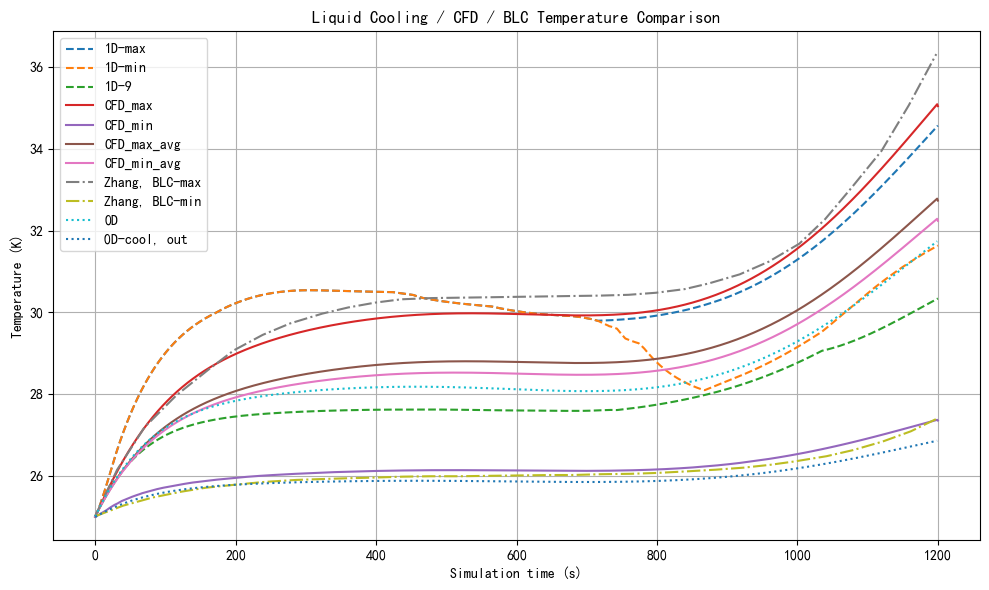

Loaded CFD series: CFD_max rows=1201, CFD_min rows=1201, CFD_max_avg rows=1201, CFD_min_avg rows=1201


In [39]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

time_s = np.arange(num_time_steps) * dt

Tmax_1D = np.array([max(T_bat_history[i]) for i in range(num_time_steps)])  # 取每个时间步最后一个电池单元的温度作为 max
T9_1D = np.array([T_bat_history[i][9] for i in range(num_time_steps)])

Tmin_1D = np.array([T_bat_history[i][5] for i in range(num_time_steps)]) # Liu told me that the 10th battery cell typically has the minimum temperature
# Tmin_1D = np.array([min(T_bat_history[i]) for i in range(num_time_steps)])   # 取每个时间步第一个电池单元的温度作为 min

plt.plot(time_s, Tmax_1D, linestyle="--", label="1D-max")
plt.plot(time_s, Tmin_1D, linestyle="--", label="1D-min")
plt.plot(time_s, T9_1D, linestyle="--", label="1D-9")

# 绘制所有已成功读取的 CFD 数据，包括新增的 CFD_min_avg / CFD_max_avg。
for label, data in cfd_series:
    plt.plot(data["time_s"], data["temperature"], label=label)    

plt.plot(BLC_max[:, 0], BLC_max[:, 1]-273.15, linestyle='-.', label="Zhang, BLC-max")
plt.plot(BLC_min[:, 0], BLC_min[:, 1]-273.15, linestyle='-.', label="Zhang, BLC-min")

# plot battery temperature without cooling for reference
# plt.plot(time_s, T_bat_wo_cooling, linestyle=":", label="1D-wo-cooling")

# plot the battery temperature calculated from the 0D model for reference
plt.plot(time_s[:-1], T_bat_history_0D[:-1], linestyle=":", label="0D")
plt.plot(time_s[:-1], T_cool_history_0D[:-1], linestyle=":", label="0D-cool, out")

# set the range of the y-axis for temperature comparison
# plt.ylim(23, 60)

plt.xlabel("Simulation time (s)")
plt.ylabel("Temperature (K)")
plt.title("Liquid Cooling / CFD / BLC Temperature Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()

# plot_path = os.path.join(output_dir, "plot_liquid_cfd_avg_comparison.png")
# plt.savefig(plot_path, dpi=600)
plt.show()

# print(f"Saved comparison plot to: {plot_path}")
if cfd_series:
    print("Loaded CFD series:", ", ".join([f"{label} rows={len(data)}" for label, data in cfd_series]))
else:
    print("WARNING: no CFD .out files were loaded. Please check CFD_DATA_DIR and CFD_SERIES_FILES.")


ValueError: x and y must have same first dimension, but have shapes (1199,) and (14,)

<Figure size 1000x600 with 0 Axes>

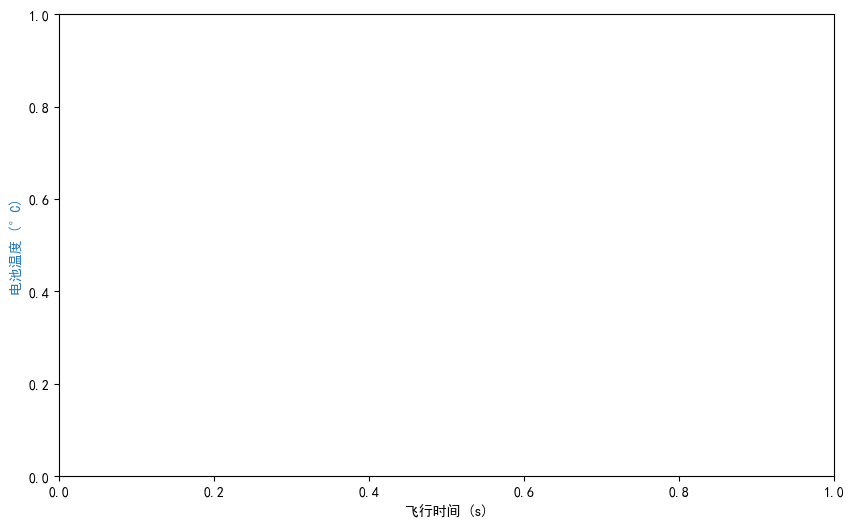

In [40]:
# in this part, plot the battery temperature profile over time steps with and without air cooling, and the power generation profile for analysis

import matplotlib.pyplot as plt
# Add support to display Chinese characters in the plot
plt.rcParams['font.sans-serif'] = ['SimHei']  # Use SimHei font for Chinese characters
plt.rcParams['axes.unicode_minus'] = False  # Ensure that

plt.figure(figsize=(10, 6))

time_array = np.arange(len(power_generation_data)) * dt  # create an array of time values corresponding to the time steps

# remove the last time step which contains an error
time_array = time_array[:-1]
T_bat_plot = T_bat[:-1]
power_plot = power_generation_data[:-1]  

# plot two y-axes for battery temperature and power generation
fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.set_xlabel('飞行时间 (s)')
ax1.set_ylabel('电池温度 (°C)', color=color)
ax1.plot(time_array, T_bat_plot, label='电池温度', color=color, linestyle='-')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')    
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('功率生成 (W)', color=color)  # we already handled the x-label with ax1
ax2.plot(time_array, power_generation_data[:-1], label='功率生成', color=color, linestyle='-')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')
plt.title('电池温度和功率生成随时间变化')
plt.grid()
plt.show()

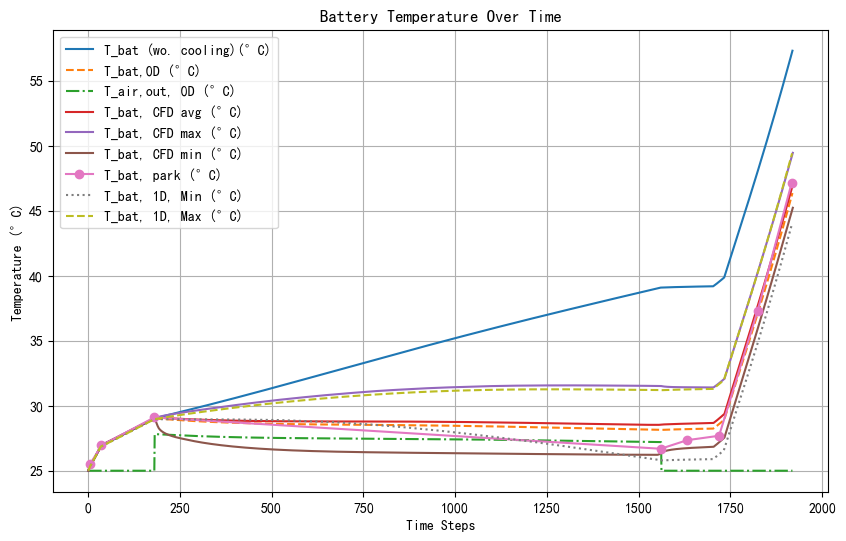

In [ ]:
# plot the battery temperature over time
import matplotlib.pyplot as plt

# set up the plot font for scientfic visualization
# plt.rcParams['font.sans-serif'] = ['SimHei']  # use the SimHei font for sans-serif text
# plt.rcParams['mathtext.fontset'] = 'dejavuserif'  # use STIX font for math text
plt.rcParams['axes.unicode_minus'] = False  # Ensure that
plt.figure(figsize=(10, 6))
plt.plot(T_bat, label='T_bat (wo. cooling)(°C)')
# plot the battery temperature under air cooling as a dashed line
plt.plot(T_bat_0D, label='T_bat,0D (°C)', linestyle='--')

# plot the air outlet temperature profile for analysis
plt.plot(T_air_out_0D, label='T_air,out, 0D (°C)', linestyle='-.') # convert to Celsius for plotting

# plot the CFD temperature data for comparison
for t, (flow_time_cfd, report_def_0_cfd) in temperature_cfd_data.items():
    plt.plot(flow_time_cfd, report_def_0_cfd - 273.15, label=f'T_bat, CFD {t} (°C)') # convert CFD temperature from K to °C for plotting   

# plot the band between the max and min CFD temperatures to visualize the range of CFD predictions
# plt.fill_between(temperature_cfd_data['min'][0], temperature_cfd_data['min'][1] - 273.15, temperature_cfd_data['max'][1] - 273.15, color='gray', alpha=0.3, label='CFD Temperature Range (°C)') # convert CFD temperatures from K to °C for plotting

# plot the experimental temperature data from Park's paper for comparison
t_park = [6, 36, 180, 1560, 1632, 1719, 1824, 1917]
T_park = [298.7, 300.1, 302.25, 299.84, 300.5, 300.84, 310.45, 320.31] # Park's experimental temperature data in Kelvin

plt.plot(t_park, np.array(T_park) - 273.15, label='T_bat, park (°C)', marker='o') # convert Park's temperature from K to °C for plotting

# plot the battery temperature calculated using the one-dimensional finite difference method for the air cooling case as a dashed line
T_bat_air_fd_min = np.array([T_bat_history[i][0] for i in range(num_time_steps)]) # minimum battery temperature across segments at each time step

T_bat_air_fd_max = np.array([T_bat_history[i][-1] for i in range(num_time_steps)]) # maximum battery temperature across segments at each time step

plt.plot(T_bat_air_fd_min[:-1], label='T_bat, 1D, Min (°C)', linestyle=':') # plot the minimum battery temperature across segments as a dotted line
plt.plot(T_bat_air_fd_max[:-1], label='T_bat, 1D, Max (°C)', linestyle='--') # plot the maximum battery temperature across segments as a dotted line
# plt.fill_between(range(len(T_bat_air_0D)), T_bat_air_fd_min, T_bat_air_fd_max, color='blue', alpha=0.1, label='Battery Temperature Range with Air Cooling (1D FD) (°C)') # fill the area between the minimum and maximum battery temperatures across segments to visualize the range of temperatures predicted by the 1D finite difference method

T_cool_air_fd = np.array([T_air_history[i][1] for i in range(num_time_steps)]) # coolant temperature at the second segment (example) across time steps for analysis
T_cool_air_fd_out = np.array([T_air_history[i][-1] for i in range(num_time_steps)]) # coolant temperature at the last segment (outlet) across time steps for analysis


plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.title('Battery Temperature Over Time')
plt.legend()
plt.grid()
plt.show()

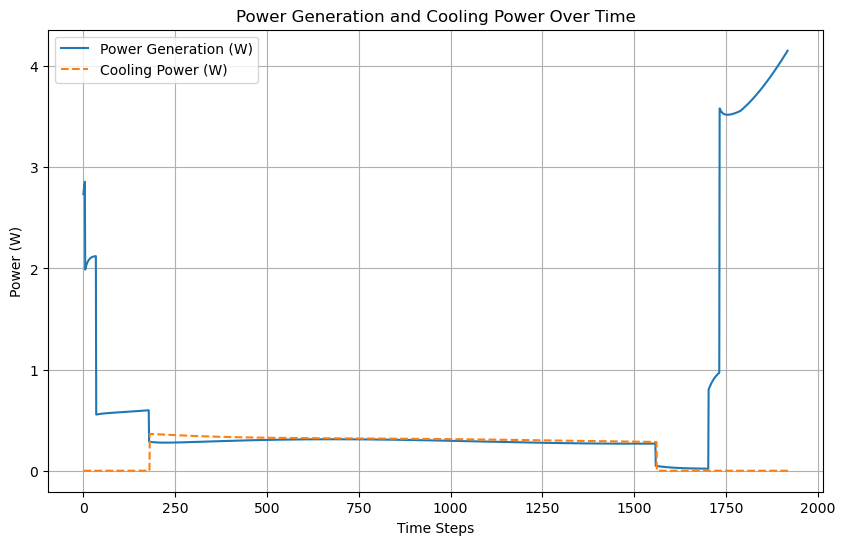

In [ ]:
# plot the power generation and cooling power profiles
plt.figure(figsize=(10, 6))
plt.plot(power_generation_data, label='Power Generation (W)')
plt.plot(Q_cool_air_profile, label='Cooling Power (W)', linestyle='--')
plt.xlabel('Time Steps')
plt.ylabel('Power (W)')
plt.title('Power Generation and Cooling Power Over Time')
plt.legend()
plt.grid()
plt.show()